# ASOS Product Catalogue Analysis 🛍️

## Contexte
Ce projet analyse le catalogue produits d'ASOS, l'un des plus grands retailers de mode en ligne.  
Le dataset contient ~30 000 produits avec des informations sur les prix, marques, catégories, couleurs et disponibilité des tailles.

**Source** : Kaggle — ASOS Product Dataset  
**Outils** : Python, Pandas, Matplotlib, Seaborn  
**Projet** : BeCode Data Bootcamp — BXL-Bouman-10

## Objectif
Identifier des insights business actionnables sur la stratégie de catalogue, le positionnement prix et la gestion des stocks d'ASOS, à travers une analyse exploratoire structurée.

## Structure de l'analyse
1. Catalogue & Concentration des marques
2. Stratégie prix
3. Gestion des stocks & ruptures
4. Diversité des tailles
5. Tendances couleurs
6. Synthèse & Recommandations

In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/processed/asos_clean.csv")

df = df.dropna()


## 1. Catalogue et concentration des marques

### ASOS mise-t-elle sur ses propres marques ou sur des marques externes ?

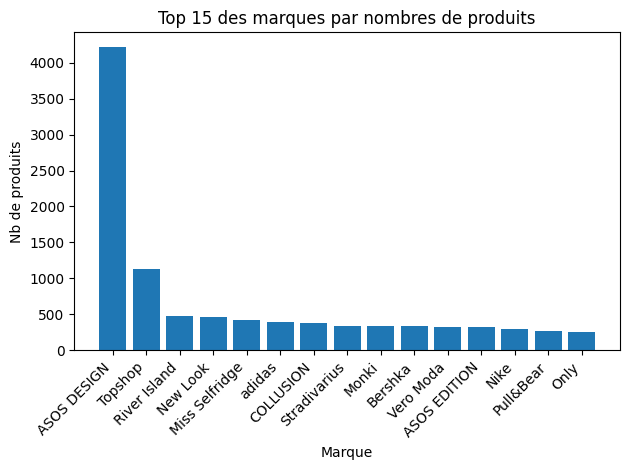

In [13]:
top15 = df["brand_group"].value_counts().head(15)

plt.bar(top15.index, top15.values)
plt.title("Top 15 des marques par nombres de produits")
plt.xlabel("Marque")
plt.ylabel("Nb de produits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Insight : ASOS DESIGN domine massivement le catalogue avec ~4200 produits, soit presque 4x plus que la deuxième marque (Topshop). Les marques tierces comme adidas, Nike ou River Island ont une présence marginale, ce qui confirme la stratégie own-brand d'ASOS.

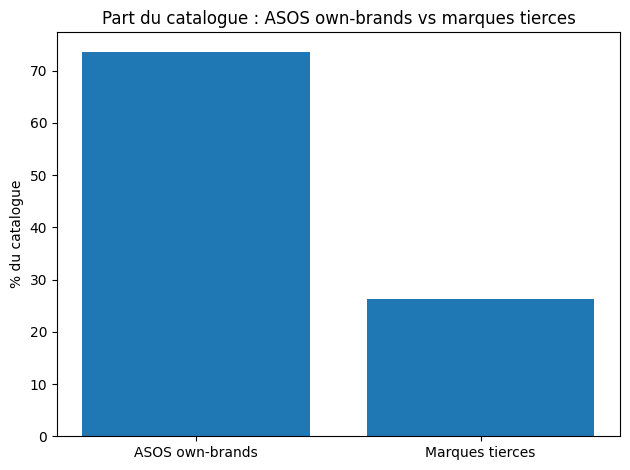

In [14]:
# Créer la colonne
df["is_asos"] = df["brand_group"].str.contains("ASOS", case=False)

# Ratio
ratio = df["is_asos"].value_counts(normalize=True) * 100

# Visualisation
plt.bar(["ASOS own-brands", "Marques tierces"], ratio.values)
plt.title("Part du catalogue : ASOS own-brands vs marques tierces")
plt.ylabel("% du catalogue")
plt.tight_layout()
plt.show()

Insight : Les marques ASOS représentent ~73% du catalogue, ce qui révèle une stratégie clairement orientée vers ses propres marques. ASOS maîtrise ainsi ses marges et réduit sa dépendance aux fournisseurs externes.

-----------------------------------------------

## 2. Stratégie prix

### ASOS se positionne-t-il comme un acteur accessible ou premium ?

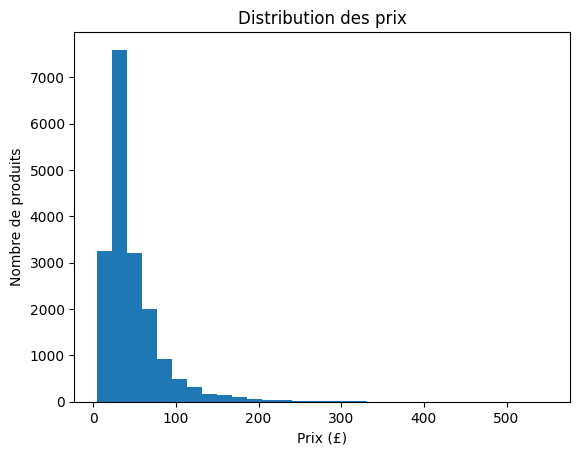

In [15]:
#Distribution des prix

plt.hist(df["price"], bins=30) 

plt.title("Distribution des prix")
plt.xlabel("Prix (£)")
plt.ylabel("Nombre de produits")
plt.show()

 Insight : Les prix de la plupart des vêtements ASOS se situe entre 20£ et 40£, ce qui montre un positionnement mid-market accessible. Le graphique montre aussi une offre premium pas très grande mais présente.

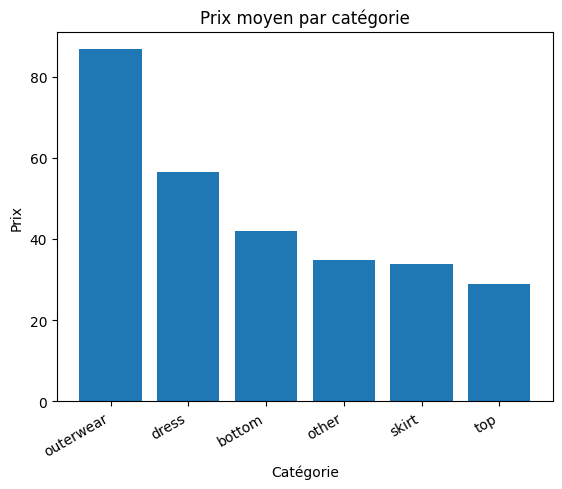

In [16]:
#Prix moyen par catégorie

price_per_cat = df.groupby("category")["price"].mean()
b = price_per_cat.sort_values(ascending=False)

plt.bar(b.index, b.values) 

plt.title("Prix moyen par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Prix")
plt.xticks(rotation=30, ha="right")  # ← rotation pour lisibilité
plt.show()

 Insight : Le prix moyen est logiquement plus élevé pour les vêtements outerwear (~90£), les tops restent les plus accèsbiles (~30£) et l'ensembles des catégories est en dessous de (~90£). Cela démontre bien le positionnement mid-market d'asos.

--------------------------------------------------

## 3. Gestion des stocks et ruptures

### Quelles catégories/marques souffrent le plus de ruptures de tock ? 

In [17]:
has_oos_rate = df["has_out_of_stock"].mean() * 100

print(f"Le taux de produits avec un out of stock est de {has_oos_rate:1f}")

Le taux de produits avec un out of stock est de 53.661987


Insight : 53.6% des produits ont au moins une taille en rupture de stock, ce qui indique une demande qui dépasse régulièrement l'offre. ASOS devrait revoir ses volumes de réapprovisionnement, notamment pour les tailles les plus populaires.

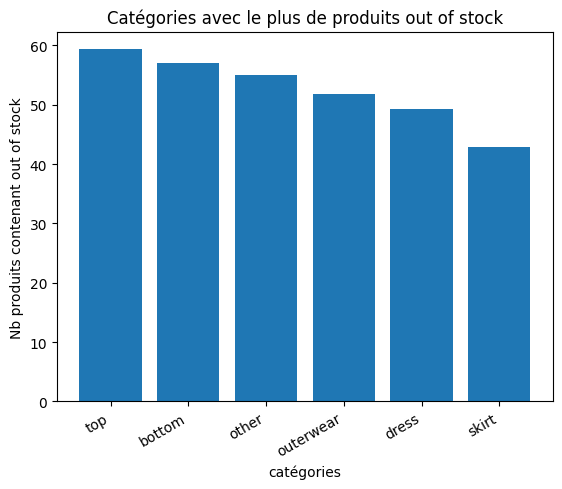

In [18]:
#% de produits out of stock par catégorie

a = df.groupby("category")["has_out_of_stock"].mean() * 100
b = a.sort_values(ascending=False)

plt.bar(b.index, b.values) 

plt.title("Catégories avec le plus de produits out of stock")
plt.xlabel("catégories")
plt.ylabel("Nb produits contenant out of stock")
plt.xticks(rotation=30, ha="right")  # ← rotation pour lisibilité
plt.show()

Insight : Les taux de rupture sont relativement homogènes entre les catégories (~60%), avec les tops et bottoms légèrement en tête. Cela suggère un problème de gestion des stocks qui touche l'ensemble du catalogue ASOS, plutôt qu'une catégorie spécifique.

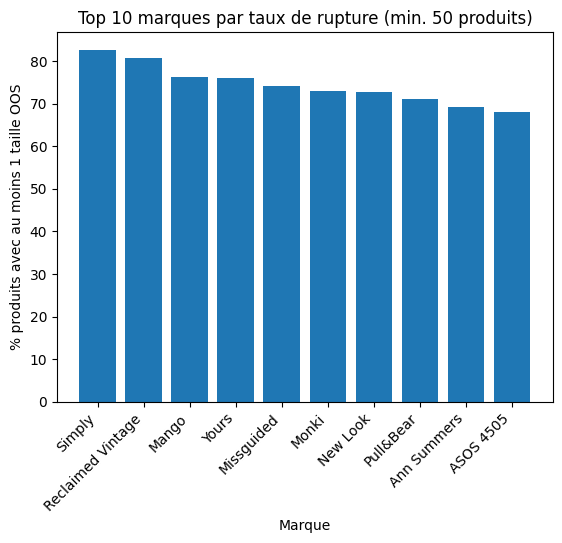

In [19]:
# Garder seulement les marques avec au moins 30 produits
brand_counts = df["brand_group"].value_counts()
brands_significatives = brand_counts[brand_counts >= 50].index

df_filtered = df[df["brand_group"].isin(brands_significatives)]

# Recalculer le taux sur ce df filtré
oos_rate = df_filtered.groupby("brand_group")["has_out_of_stock"].mean() * 100
oos_rate = oos_rate.sort_values(ascending=False).head(10)

plt.bar(oos_rate.index, oos_rate.values)
plt.title("Top 10 marques par taux de rupture (min. 50 produits)")
plt.xlabel("Marque")
plt.ylabel("% produits avec au moins 1 taille OOS")
plt.xticks(rotation=45, ha="right")
plt.show()

Insight : Les taux de rupture sont relativement homogènes entre le top 10 des marques (70%-80%), avec Simply et Reclaimed vintage légèrement en tête. Cela suggère un problème de gestion des stocks qui touche l'ensemble du top10, plutôt qu'une marque spécifique.

------------------------------------------

## 4. Diversité des tailles ? 

### L'offre de tailles est-elle homogène selon les catégories ? 

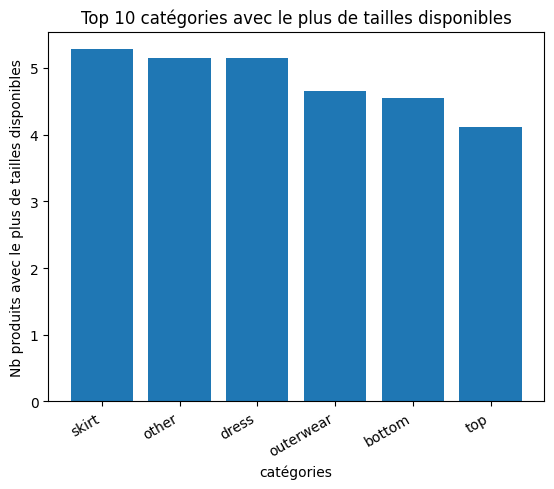

In [20]:
#Top 10 catégories avec le plus de tailles disponibles

a = df.groupby("category")["nb_sizes_available"].mean()
b = a.sort_values(ascending=False)

plt.bar(b.index, b.values) 

plt.title("Top 10 catégories avec le plus de tailles disponibles")
plt.xlabel("catégories")
plt.ylabel("Nb produits avec le plus de tailles disponibles")
plt.xticks(rotation=30, ha="right")  # ← rotation pour lisibilité
plt.show()

Insight : Le nombre moyen de tailles disponibles est homogène entre les catégories (4-5 tailles), ce qui indique une gestion cohérente de l'offre de tailles sur l'ensemble du catalogue.

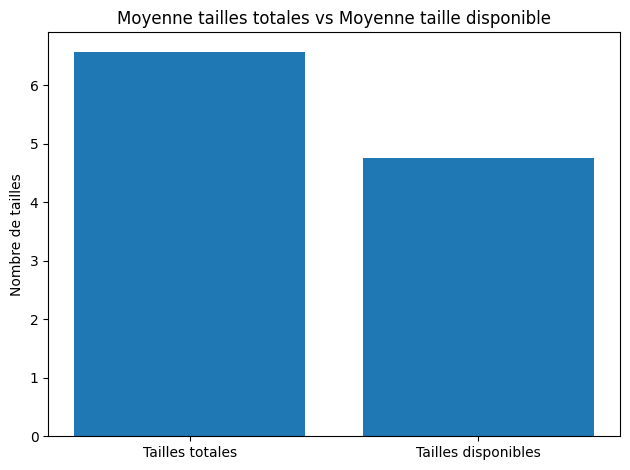

In [21]:
mean = [df["nb_sizes_total"].mean(), df["nb_sizes_available"].mean()]
labels = ["Tailles totales", "Tailles disponibles"]

# Visualisation
plt.bar(labels,mean)
plt.title("Moyenne tailles totales vs Moyenne taille disponible")
plt.ylabel("Nombre de tailles")
plt.tight_layout()
plt.show()

Insight : En moyenne, 2 tailles sur 6.6 sont en rupture par produit, soit ~30% de l'offre de tailles indisponible. Combiné au fait que 53% des produits ont au moins une taille OOS, cela confirme un problème structurel de réapprovisionnement chez ASOS.

----------------------------------------

## 5. Tendances couleurs

### Quelles couleurs dominent l'offre ? Y'a-t-il des patterns par catégorie . 

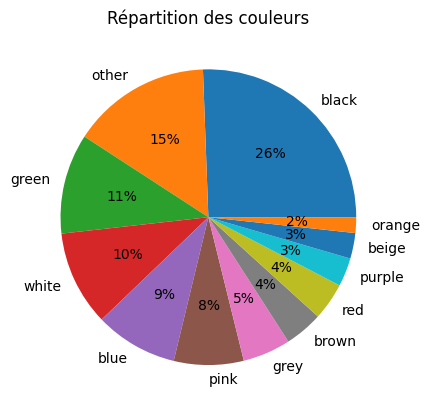

In [22]:
colors = df["base_color"].value_counts()

plt.pie(colors, labels=colors.index, autopct="%1.f%%")
plt.title("Répartition des couleurs")
plt.show()

Insight : le noir domine largement le catalogue avec 26% des produits, suivi par "other" (15%) et vert (11%). Cette dominance du noir est cohérente avec les tendances mode — c'est la couleur la plus polyvalente et la plus demandée. L'orange et le beige sont marginaux (~2-3%), ce qui reflète leur caractère plus saisonnier.

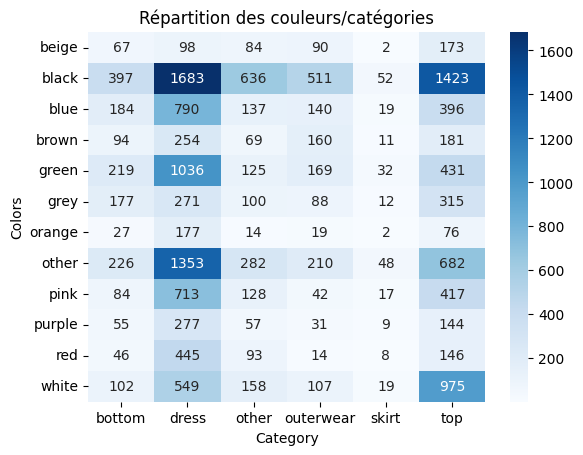

In [23]:
tableau = pd.crosstab(df["base_color"], df["category"])

sns.heatmap(tableau, annot=True, fmt="d", cmap="Blues")
plt.title("Répartition des couleurs/catégories")
plt.ylabel("Colors")
plt.xlabel("Category")
plt.show()

 Insight : le noir est la couleur dominante dans presque toutes les catégories, particulièrement pour les robes (1683) et les tops (1423). Le vert ressort fortement dans les robes (1036), ce qui peut indiquer une tendance mode spécifique à cette catégorie. Le blanc est bien représenté dans les tops (975), cohérent avec les basiques du quotidien.

------------------------------------------

## 6. Synthèse & Recommandations

### Ce que les données nous disent


- Les marques ASOS représentent ~73% du catalogue, confirmant une stratégie de marque propre dominante qui réduit la dépendance aux fournisseurs externes.

- Le positionnement prix est clairement mid-market (cœur de l'offre entre £20-£50), avec l'outerwear comme catégorie premium (~£88 en moyenne).

- 53% des produits ont au moins une taille en rupture de stock, avec un taux homogène entre catégories (45%-60%) et entre marques — ce qui suggère un problème structurel plutôt qu'isolé.

- Le noir domine le catalogue (26%), cohérent avec les tendances mode, tandis que le vert ressort dans les robes (1036 produits).


### Recommandations 

- **Gestion des stocks** : Revoir les volumes de réapprovisionnement sur l'ensemble du catalogue — 53% de produits avec une taille OOS et ~30% de l'offre de tailles indisponible indiquent un problème systémique qui impacte l'expérience client.

- **Stratégie own-brand** : Maintenir la dominance des marques ASOS pour préserver les marges et l'indépendance vis-à-vis des fournisseurs externes.

- **Opportunité couleur** : Le vert surreprésenté dans les robes suggère une tendance à exploiter — envisager d'élargir l'offre verte dans d'autres catégories comme les tops et bottoms.